In [1]:
import pandas as pd, numpy as np
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.shape

(7043, 21)

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [3]:
df["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [4]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].isna().sum()

np.int64(11)

In [5]:
df[df["TotalCharges"].isna()][["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


In [6]:
df["Churn"] = np.where(df["Churn"] == "Yes", 1, 0)
df.duplicated().sum(), df["Churn"].mean()

(np.int64(0), np.float64(0.2653698707936959))

In [7]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)
df["TotalCharges"].isna().sum()

np.int64(0)

In [8]:
df["tenure_group"] = pd.cut(df["tenure"], bins = [-1, 12, 24, 48, 72], labels=["0-12", "13-24", "25-48", "49+"])
df["tenure_group"].value_counts

<bound method IndexOpsMixin.value_counts of 0        0-12
1       25-48
2        0-12
3       25-48
4        0-12
        ...  
7038    13-24
7039      49+
7040     0-12
7041     0-12
7042      49+
Name: tenure_group, Length: 7043, dtype: category
Categories (4, str): ['0-12' < '13-24' < '25-48' < '49+']>

In [9]:
df["avg_monthly_spend"] = np.where(df["tenure"] > 0, df["TotalCharges"]/df["tenure"], df["MonthlyCharges"])
df[["tenure", "TotalCharges", "avg_monthly_spend"]].head()

,tenure,TotalCharges,avg_monthly_spend
0,1,29.85,29.850000
1,34,1889.50,55.573529
2,2,108.15,54.075000
3,45,1840.75,40.905556
4,2,151.65,75.825000


In [10]:
service_cols = ["PhoneService", "MultipleLines", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
df["num_services"] = (df[service_cols] == "Yes").sum(axis=1)
df["num_services"].value_counts().sort_index()

num_services
0      80
1    1701
2    1188
3     965
4     922
5     908
6     676
7     395
8     208
Name: count, dtype: int64

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df.groupby("Contract")["Churn"].mean()

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64

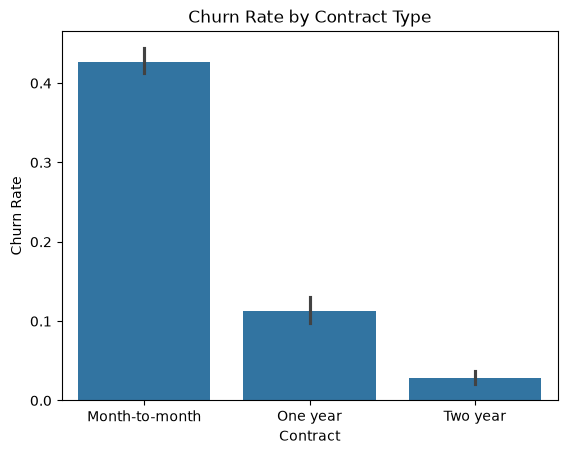

In [13]:
sns.barplot(x=df["Contract"], y=df["Churn"])
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate")
plt.show()

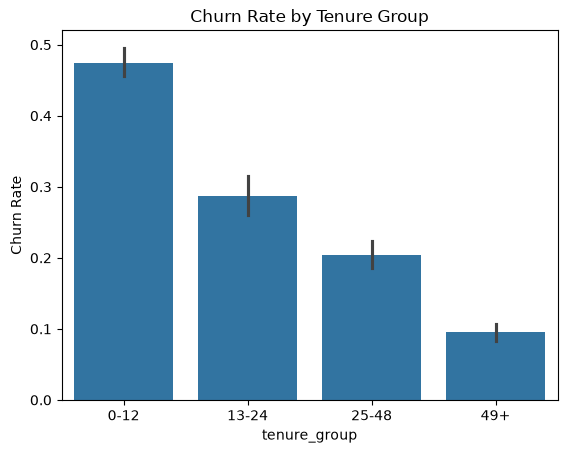

In [14]:
sns.barplot(x=df["tenure_group"], y=df["Churn"], order=["0-12", "13-24", "25-48", "49+"])
plt.title("Churn Rate by Tenure Group")
plt.ylabel("Churn Rate")
plt.show()

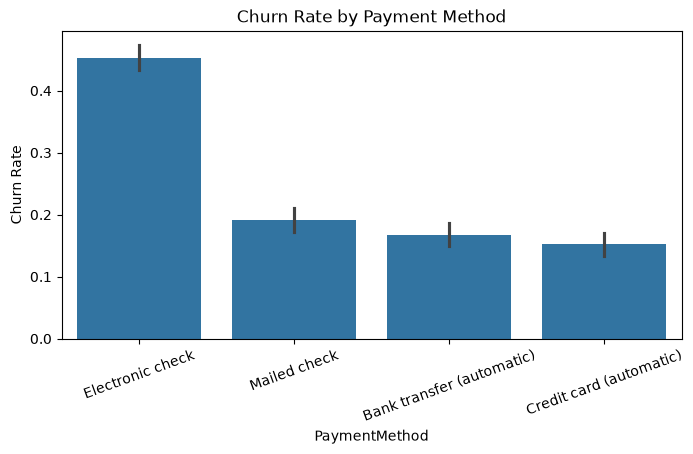

In [15]:
plt.figure(figsize=(8, 4))
sns.barplot(x=df["PaymentMethod"], y=df["Churn"])
plt.title("Churn Rate by Payment Method")
plt.ylabel("Churn Rate")
plt.xticks(rotation=20)
plt.show()

Electronic check customers churn about 3x more than automatic payment customers.

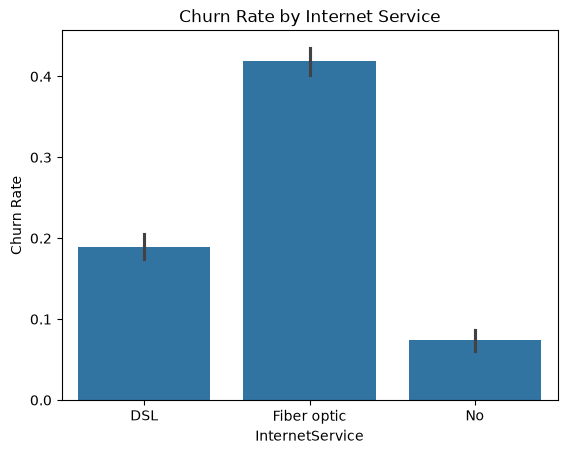

In [16]:
sns.barplot(x=df["InternetService"], y=df["Churn"])
plt.title("Churn Rate by Internet Service")
plt.ylabel("Churn Rate")
plt.show()

In [17]:
from scipy.stats import chi2_contingency
table = pd.crosstab(df["Contract"], df["Churn"])
table

Churn,0,1
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [18]:
chi2, p, dof, expected = chi2_contingency(table)
p

np.float64(5.863038300673391e-258)

In [19]:
table2 = pd.crosstab(df["InternetService"], df["Churn"])
chi2, p2, dof, expected = chi2_contingency(table2)
p2


np.float64(9.571788222840544e-160)

In [20]:
table3 = pd.crosstab(df["PaymentMethod"], df["Churn"])
chi2, p3, dof, expected = chi2_contingency(table3)
p3

np.float64(3.6823546520097993e-140)

In [21]:
pd.crosstab(df["PaymentMethod"], df["Contract"], normalize="index")


Contract,Month-to-month,One year,Two year
PaymentMethod,,,
Bank transfer (automatic),0.381477,0.253238,0.365285
Credit card (automatic),0.356767,0.261498,0.381735
Electronic check,0.782241,0.146723,0.071036
Mailed check,0.553970,0.209057,0.236973


In [22]:
df[df["Contract"] == "Month-to-month"].groupby("PaymentMethod")["Churn"].mean()


PaymentMethod
Bank transfer (automatic)    0.341256
Credit card (automatic)      0.327808
Electronic check             0.537297
Mailed check                 0.315789
Name: Churn, dtype: float64

In [23]:
from sklearn.preprocessing import StandardScaler
features = df[["tenure", "MonthlyCharges", "num_services"]]
scaled = StandardScaler().fit_transform(features)
scaled[:3]

array([[-1.27744458, -1.16032292, -1.14599684],
       [ 0.06632742, -0.25962894, -0.17601057],
       [-1.23672422, -0.36266036, -0.17601057]])

In [24]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["segment"] = kmeans.fit_predict(scaled)
df["segment"].value_counts().sort_index()

segment
0    1557
1    2144
2    2315
3    1027
Name: count, dtype: int64

In [25]:
df.groupby("segment")[["tenure", "MonthlyCharges", "num_services", "Churn"]].mean().round(2)

,tenure,MonthlyCharges,num_services,Churn
segment,,,,
0,10.27,29.89,1.26,0.24
1,56.78,92.10,5.77,0.16
2,14.79,77.60,3.22,0.47
3,54.56,31.63,1.85,0.05


In [26]:
names = {0: "New & Basic", 1: "Loyal Premium", 2: "At-Risk Mid-Tier", 3: "Loyal Budget"}
df["segment_name"] = df["segment"].map(names)
df.groupby("segment_name")["Churn"].agg(["count", "mean", "sum"]).round(2)

,count,mean,sum
segment_name,,,
At-Risk Mid-Tier,2315,0.47,1099
Loyal Budget,1027,0.05,49
Loyal Premium,2144,0.16,344
New & Basic,1557,0.24,377


In [27]:
X = pd.get_dummies(df.drop(columns=["customerID", "Churn", "segment", "segment_name"]), drop_first=True)
y = df["Churn"]
X.shape

(7043, 35)

In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape, X_test.shape

((5634, 35), (1409, 35))

In [29]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
pred = model.predict(X_test)

C:\Users\Aryaan\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [30]:
from sklearn.metrics import classification_report
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [31]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

model2 = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight="balanced"))
model2.fit(X_train, y_train)
pred2 = model2.predict(X_test)
print(classification_report(y_test, pred2))

              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1035
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.73      0.75      1409



In [32]:
from xgboost import XGBClassifier
ratio = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05, scale_pos_weight=ratio, random_state=42)
xgb.fit(X_train, y_train)
pred3 = xgb.predict(X_test)
print(classification_report(y_test, pred3))

              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.51      0.81      0.63       374

    accuracy                           0.74      1409
   macro avg       0.71      0.77      0.72      1409
weighted avg       0.81      0.74      0.76      1409



In [33]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

preds = [pred, pred2, pred3]
probs = [model.predict_proba(X_test)[:, 1], model2.predict_proba(X_test)[:, 1], xgb.predict_proba(X_test)[:, 1]]

results = pd.DataFrame({
    "Model": ["Logistic (plain)", "Logistic (balanced)", "XGBoost"],
    "Precision": [precision_score(y_test, p) for p in preds],
    "Recall": [recall_score(y_test, p) for p in preds],
    "F1": [f1_score(y_test, p) for p in preds],
    "ROC-AUC": [roc_auc_score(y_test, pr) for pr in probs],
}).round(3)
results

,Model,Precision,Recall,F1,ROC-AUC
0,Logistic (plain),0.655,0.519,0.579,0.843
1,Logistic (balanced),0.500,0.794,0.614,0.842
2,XGBoost,0.511,0.813,0.627,0.842


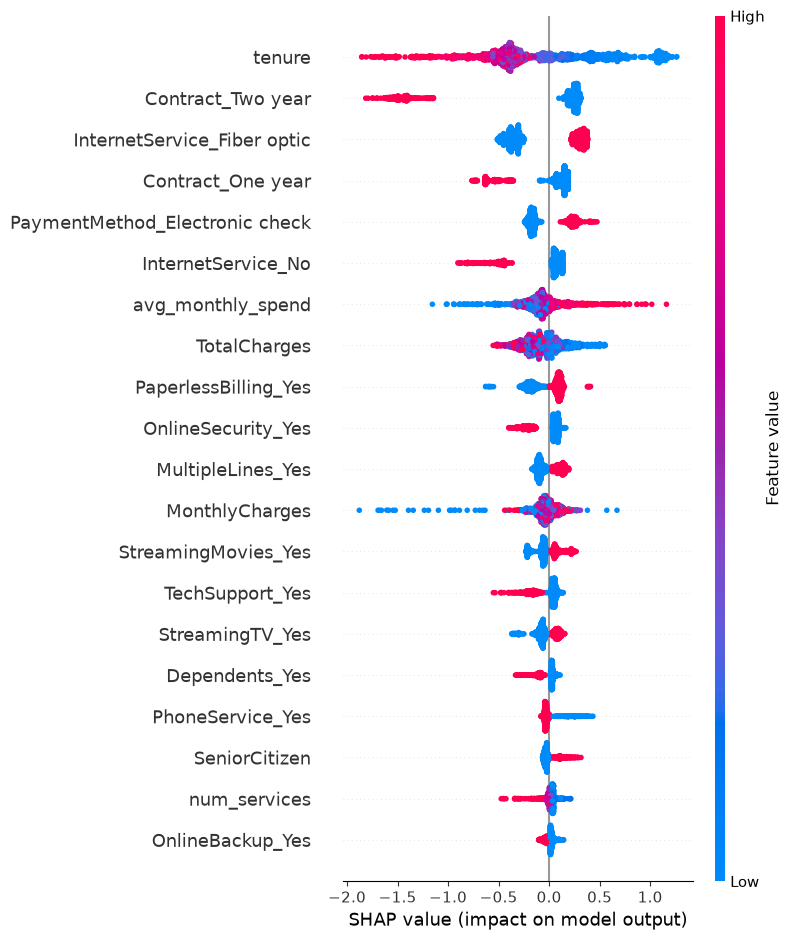

In [34]:
import shap
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

In [35]:
i = 0
contrib = pd.Series(shap_values[i], index=X_test.columns).sort_values(ascending=False)
prob = xgb.predict_proba(X_test.iloc[[i]])[0, 1]
print(f"Churn probability: {prob:.0%}")
contrib.head(3)

Churn probability: 4%


avg_monthly_spend              0.385657
InternetService_Fiber optic    0.229822
gender_Male                    0.123852
dtype: float32

In [36]:
import joblib
joblib.dump(xgb, "../src/churn_model.joblib")
joblib.dump(list(X.columns), "../src/model_columns.joblib")

['../src/model_columns.joblib']